In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

2025-07-10 17:24:43.008908: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752168283.224770      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752168283.287738      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
train_path='/kaggle/input/intel-image-classification/seg_train/seg_train'
test_path='/kaggle/input/intel-image-classification/seg_test/seg_test'

train_dataset=tf.keras.utils.image_dataset_from_directory(
    train_path,
    shuffle=True,
    batch_size=64,
    image_size=(224,224),
    subset='training',
    validation_split=0.2,
    seed=42
    )

val_dataset=tf.keras.utils.image_dataset_from_directory(
    train_path,
    shuffle=True,
    batch_size=64,
    image_size=(224,224),
    subset='validation',
    validation_split=0.2,
    seed=42
)


test_dataset=tf.keras.utils.image_dataset_from_directory(
    test_path,
    batch_size=64,
    image_size=(224,224),
)

class_names = train_dataset.class_names

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


I0000 00:00:1752168303.901734      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.


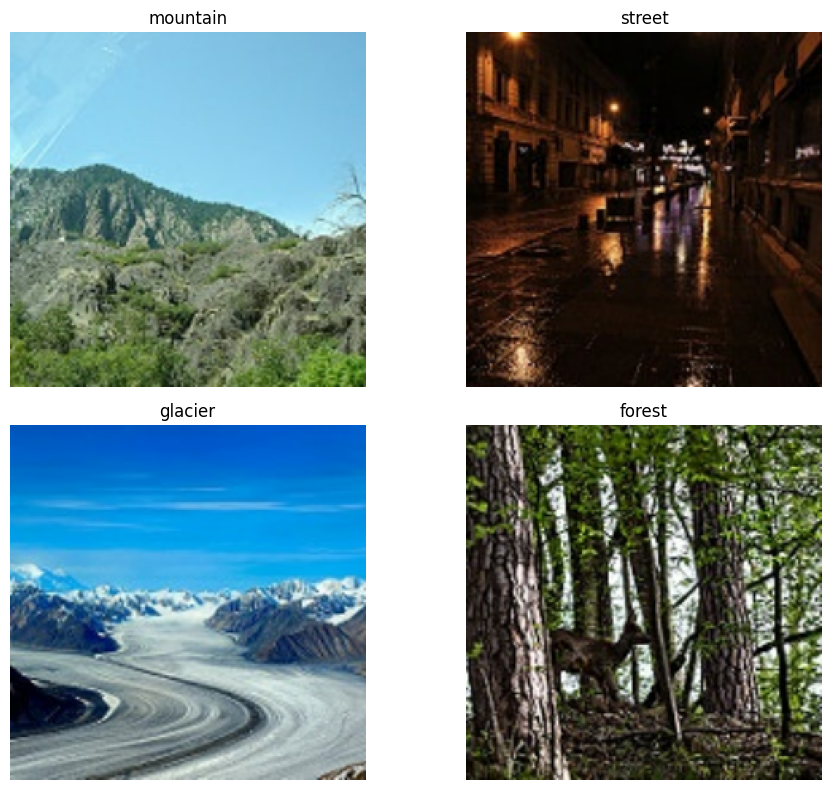

In [3]:
plt.figure(figsize=(10, 8))
for image_batch, image_labels in train_dataset.take(1): 
    for i in range(4):
        plt.subplot(2, 2, i + 1)
        plt.imshow(image_batch[i].numpy().astype(np.uint8))
        plt.title(class_names[image_labels[i].numpy()])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [4]:
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomRotation(0.1),
])

augmented_train_dataset = train_dataset.map(lambda x, y: (data_aug(x), y))

In [5]:
model=tf.keras.Sequential([
    data_aug,
    
    tf.keras.layers.Rescaling(1./255,input_shape=(224,224,3)),

    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(256,(3,3),activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(class_names),activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,109,830 (19.49 MB)

 Trainable params: 5,108,870 (19.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [6]:
EarlyStopping=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    
    
ReduceLROnPlateau=tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        verbose=1
    )

In [7]:
history=model.fit(train_dataset,epochs=20,validation_data=val_dataset,callbacks=[EarlyStopping,ReduceLROnPlateau])

Epoch 1/20


I0000 00:00:1752168318.679752      64 cuda_dnn.cc:529] Loaded cuDNN version 90300


176/176 ━━━━━━━━━━━━━━━━━━━━ 39s 167ms/step - accuracy: 0.3384 - loss: 3.0641 - val_accuracy: 0.2038 - val_loss: 4.7311 - learning_rate: 0.0010
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 146ms/step - accuracy: 0.4338 - loss: 1.4408 - val_accuracy: 0.2598 - val_loss: 1.7285 - learning_rate: 0.0010
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 146ms/step - accuracy: 0.4429 - loss: 1.3956 - val_accuracy: 0.5870 - val_loss: 1.1543 - learning_rate: 0.0010
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 146ms/step - accuracy: 0.4996 - loss: 1.2117 - val_accuracy: 0.5371 - val_loss: 1.1326 - learning_rate: 0.0010
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 145ms/step - accuracy: 0.5416 - loss: 1.1920 - val_accuracy: 0.6237 - val_loss: 1.0327 - learning_rate: 0.0010
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 145ms/step - accuracy: 0.5503 - loss: 1.1496 - val_accuracy: 0.6842 - val_loss: 0.8796 - learning_rate: 0.0010
Epoch 7/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 145ms/step - accuracy: 0.5823 - loss:

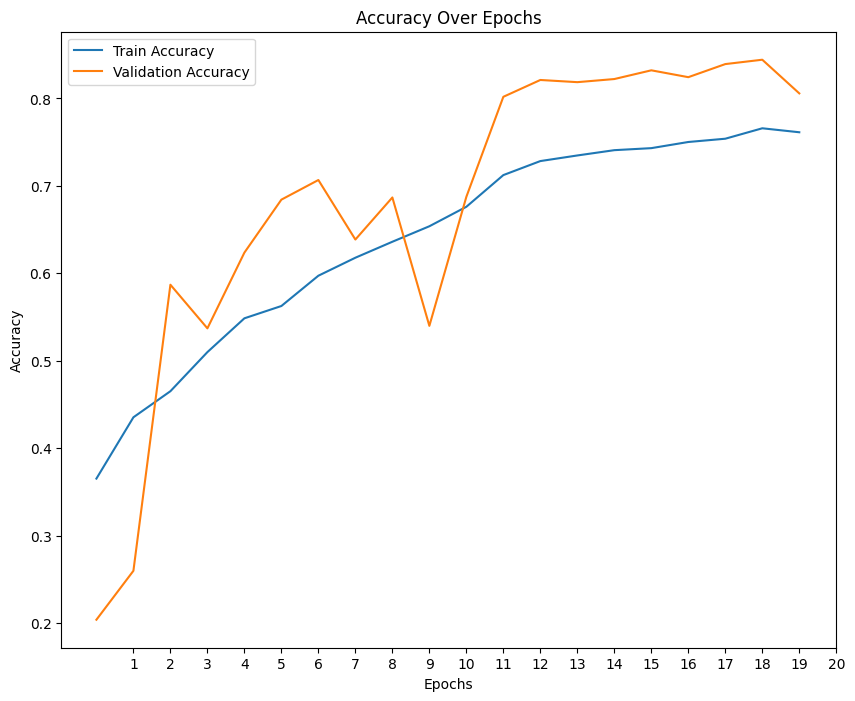

In [8]:
import pandas as pd

plt.figure(figsize=(10, 8))

plt.plot(pd.DataFrame(history.history['accuracy']), label='Train Accuracy')

plt.plot(pd.DataFrame(history.history['val_accuracy']), label='Validation Accuracy')

plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(np.arange(20)+1)
plt.legend()
plt.show()

In [9]:
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=2)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

47/47 - 4s - 80ms/step - accuracy: 0.8427 - loss: 0.4663
Test Loss: 0.4663
Test Accuracy: 0.8427
